In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
(x_train,_),(x_test,_) = tf.keras.datasets.cifar10.load_data()

x_train = (x_train.astype("float32") - 127.5)/127.5
x_test = (x_test.astype("float32") - 127.5)/127.5


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
x_train_gray = tf.image.rgb_to_grayscale(x_train)
x_test_gray = tf.image.rgb_to_grayscale(x_test)


Input → grayscale image
Output → color image



In [4]:
from tensorflow.keras import layers

def build_generator():

    inputs = layers.Input(shape=(32,32,1))

    # Encoder
    d1 = layers.Conv2D(64,4,strides=2,padding="same")(inputs)
    d1 = layers.LeakyReLU()(d1)

    d2 = layers.Conv2D(128,4,strides=2,padding="same")(d1)
    d2 = layers.LeakyReLU()(d2)

    # Decoder
    u1 = layers.UpSampling2D()(d2)
    u1 = layers.Conv2D(128,4,padding="same",activation="relu")(u1)

    u2 = layers.UpSampling2D()(u1)
    u2 = layers.Conv2D(64,4,padding="same",activation="relu")(u2)

    outputs = layers.Conv2D(3,3,padding="same",activation="tanh")(u2)

    return tf.keras.Model(inputs,outputs)

generator = build_generator()
generator.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527,427 (2.01 MB)

 Trainable params: 527,427 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
def build_discriminator():

    inp = layers.Input(shape=(32,32,1))
    tar = layers.Input(shape=(32,32,3))

    x = layers.Concatenate()([inp,tar])

    x = layers.Conv2D(64,4,strides=2,padding="same")(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(128,4,strides=2,padding="same")(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2D(1,4,padding="same")(x)

    return tf.keras.Model([inp,tar],x)

discriminator = build_discriminator()
discriminator.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32, 4) │          0 │ input_layer_1[0]… │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │      4,160 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 128) │    131,200 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 8, 8, 128) │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 1)   │      2,049 │ leaky_re_lu_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 137,409 (536.75 KB)

 Trainable params: 137,409 (536.75 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(disc_generated_output, gen_output, target):

    gan_loss = loss_object(tf.ones_like(disc_generated_output),disc_generated_output)

    l1_loss = tf.reduce_mean(tf.abs(target-gen_output))

    total_gen_loss = gan_loss + (100*l1_loss)

    return total_gen_loss


In [7]:
generator_optimizer = tf.keras.optimizers.Adam(0.0002)
discriminator_optimizer = tf.keras.optimizers.Adam(0.0002)


In [8]:
@tf.function
def train_step(input_image,target):

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        gen_output = generator(input_image,training=True)

        disc_real_output = discriminator([input_image,target],training=True)
        disc_generated_output = discriminator([input_image,gen_output],training=True)

        gen_loss = generator_loss(disc_generated_output,gen_output,target)

    gradients = gen_tape.gradient(gen_loss,generator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients,generator.trainable_variables))


In [9]:
for epoch in range(5):

    for i in range(100):

        train_step(x_train_gray[i:i+1],x_train[i:i+1])

    print("Epoch:",epoch,"completed")


Epoch: 0 completed
Epoch: 1 completed
Epoch: 2 completed
Epoch: 3 completed
Epoch: 4 completed


In [10]:
pred = generator(x_test_gray[:5])


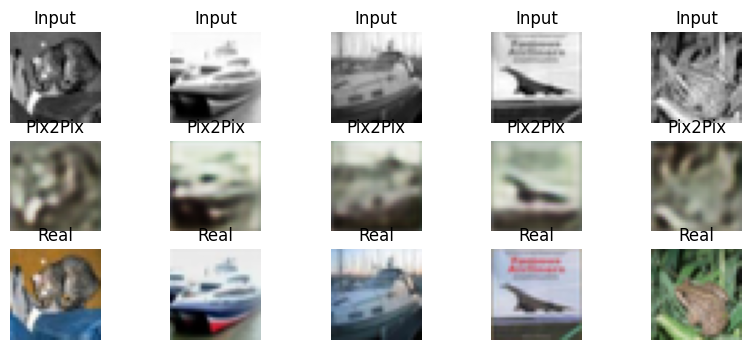

In [11]:
plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(tf.squeeze(x_test_gray[i]),cmap="gray")
    plt.axis("off")
    plt.title("Input")

    plt.subplot(3,5,i+6)
    plt.imshow((pred[i]+1)/2)
    plt.axis("off")
    plt.title("Pix2Pix")

    plt.subplot(3,5,i+11)
    plt.imshow((x_test[i]+1)/2)
    plt.axis("off")
    plt.title("Real")

plt.show()


In [12]:
img = (pred[0]+1)/2
plt.imsave("pix2pix_output.png",img)


In [13]:
from google.colab import files
files.download("pix2pix_output.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>